# KNN Regressor and BDT's Lesson 
--------------------------------------------------------------------------------------------------------------------------------------------------

# Regression: 

* KNN Processes can be performed as a regression algorithm. An example
  is predicting an IMDb rating for movies.

* This process is almost identical to classification, except for the final step. Once again, we are going to find the k nearest neighbors of the new
  movie by using the distance formula. However, instead of counting the number of good and bad neighbors, the regressor averages their IMDb ratings.

In [1]:
# Ex.) 

"""

from movies import movie_dataset, movie_ratings

def distance(movie1, movie2):
  squared_difference = 0
  for i in range(len(movie1)):
    squared_difference += (movie1[i] - movie2[i]) ** 2
  final_distance = squared_difference ** 0.5
  return final_distance

def predict(unknown, dataset, movie_ratings, k):
  distances = []
  #Looping through all points in the dataset
  for title in dataset:
    movie = dataset[title]
    distance_to_point = distance(movie, unknown)
    #Adding the distance and point associated with that distance
    distances.append([distance_to_point, title])
  distances.sort()
  #Taking only the k closest points
  neighbors = distances[0:k]
  #Looping through neighbors 
  total =  0
  for neighbor in neighbors:
    title = neighbor[1]
    total += movie_ratings[title]
  #Finding average 
  ratings =  total/(len(neighbors))
  return ratings

print(movie_dataset["Life of Pi"])
print(movie_ratings["Life of Pi"])
print(predict([0.016, 0.300, 1.022], movie_dataset, movie_ratings, 5))
"""

'\n\nfrom movies import movie_dataset, movie_ratings\n\ndef distance(movie1, movie2):\n  squared_difference = 0\n  for i in range(len(movie1)):\n    squared_difference += (movie1[i] - movie2[i]) ** 2\n  final_distance = squared_difference ** 0.5\n  return final_distance\n\ndef predict(unknown, dataset, movie_ratings, k):\n  distances = []\n  #Looping through all points in the dataset\n  for title in dataset:\n    movie = dataset[title]\n    distance_to_point = distance(movie, unknown)\n    #Adding the distance and point associated with that distance\n    distances.append([distance_to_point, title])\n  distances.sort()\n  #Taking only the k closest points\n  neighbors = distances[0:k]\n  #Looping through neighbors \n  total =  0\n  for neighbor in neighbors:\n    title = neighbor[1]\n    total += movie_ratings[title]\n  #Finding average \n  ratings =  total/(len(neighbors))\n  return ratings\n\nprint(movie_dataset["Life of Pi"])\nprint(movie_ratings["Life of Pi"])\nprint(predict([0.016,

# Weighted Regression:


- **Idea:** Instead of a plain average of the *k* neighbors' values, weight each neighbor by how *close* it is — closer neighbors count more.

  - **Why:** A plain mean treats all neighbors equally. But a point that's right next to our target should matter more than one that's far away.

  ### The formula

  - Weight each neighbor by **1 / distance** (closer → bigger weight).

  $$
  \text{prediction} = \frac{\displaystyle\sum_{i} \frac{\text{rating}_i}{\text{distance}_i}}{\displaystyle\sum_{i} \frac{1}{\text{distance}_i}}
  $$

  - **Numerator:** sum of each rating divided by its distance.
  - **Denominator:** sum of (1 / distance) over all neighbors — this normalizes the weights so they add to 1.

  ### Worked example (predicting movie X)

  | Movie | Rating | Distance to X |
  |-------|--------|---------------|
  | A     | 5.0    | 3.2           |
  | B     | 6.8    | 11.5          |
  | C     | 9.0    | 1.1           |

  - **Plain mean:** (5.0 + 6.8 + 9.0) / 3 = **6.93**
  - **Weighted average:**
    - Numerator = 5.0/3.2 + 6.8/11.5 + 9.0/1.1 = 1.5625 + 0.591 + 8.182 ≈ 10.336
    - Denominator = 1/3.2 + 1/11.5 + 1/1.1 = 0.3125 + 0.087 + 0.909 ≈ 1.309
    - Prediction = 10.336 / 1.309 ≈ **7.9**

  - **Takeaway:** Same ratings, but because X is most similar to C (smallest distance), C dominates the weighted result — pulling the prediction up from
  6.93 to ~7.9.

In [2]:
#Ex.) 

"""

from movies import movie_dataset, movie_ratings

def distance(movie1, movie2):
  squared_difference = 0
  for i in range(len(movie1)):
    squared_difference += (movie1[i] - movie2[i]) ** 2
  final_distance = squared_difference ** 0.5
  return final_distance

def predict(unknown, dataset, movie_ratings, k):
  distances = []
  #Looping through all points in the dataset
  for title in dataset:
    movie = dataset[title]
    distance_to_point = distance(movie, unknown)
    #Adding the distance and point associated with that distance
    distances.append([distance_to_point, title])
  distances.sort()
  #Taking only the k closest points
  neighbors = distances[0:k]
  numerator = 0 
  denominator = 0 
  for neighbor in neighbors: 
    rating = movie_ratings[neighbor[1]]
    distance_to_neighbor = neighbor[0]
    numerator += (rating/distance_to_neighbor)
    denominator += (1.0/ distance_to_neighbor)
  return numerator/denominator

print(predict([0.016, 0.300, 1.022], movie_dataset, movie_ratings, 5))

"""

'\n\nfrom movies import movie_dataset, movie_ratings\n\ndef distance(movie1, movie2):\n  squared_difference = 0\n  for i in range(len(movie1)):\n    squared_difference += (movie1[i] - movie2[i]) ** 2\n  final_distance = squared_difference ** 0.5\n  return final_distance\n\ndef predict(unknown, dataset, movie_ratings, k):\n  distances = []\n  #Looping through all points in the dataset\n  for title in dataset:\n    movie = dataset[title]\n    distance_to_point = distance(movie, unknown)\n    #Adding the distance and point associated with that distance\n    distances.append([distance_to_point, title])\n  distances.sort()\n  #Taking only the k closest points\n  neighbors = distances[0:k]\n  numerator = 0 \n  denominator = 0 \n  for neighbor in neighbors: \n    rating = movie_ratings[neighbor[1]]\n    distance_to_neighbor = neighbor[0]\n    numerator += (rating/distance_to_neighbor)\n    denominator += (1.0/ distance_to_neighbor)\n  return numerator/denominator\n\nprint(predict([0.016, 0.30

# Scikit-Learn


- `KNeighborsRegressor` works almost exactly like `KNeighborsClassifier` — just predicts a continuous value instead of a class.

  ### 1. Create the regressor

  ```python
  from sklearn.neighbors import KNeighborsRegressor

  regressor = KNeighborsRegressor(n_neighbors=3, weights="distance")

  - n_neighbors → sets k (how many neighbors to use).
  - weights → how to average the neighbors:
    - "uniform" — all neighbors count equally (plain mean).
    - "distance" — closer neighbors count more (weighted average, like we built by hand).

  2. Fit the model

  training_points = [
    [0.5, 0.2, 0.1],
    [0.9, 0.7, 0.3],
    [0.4, 0.5, 0.7]
  ]

  training_labels = [5.0, 6.8, 9.0]

  regressor.fit(training_points, training_labels)

  - .fit() takes two lists:
    - the points (feature vectors),
    - the values/labels for those points.
  - KNN doesn't really "train" — .fit() just stores the data to compare against later.

  3. Make predictions

  unknown_points = [
    [0.2, 0.1, 0.7],
    [0.4, 0.7, 0.6],
    [0.5, 0.8, 0.1]
  ]

  guesses = regressor.predict(unknown_points)

  - .predict() takes a list of points and returns a list of predictions (one per point).
  - Takeaway: Once you understand the manual version, scikit-learn just wraps it — pick k with n_neighbors and choose "uniform" vs "distance" for weights.

In [3]:
#Ex.) 

"""
from movies import movie_dataset, movie_ratings
from sklearn.neighbors import KNeighborsRegressor

#importing Regressor
regressor =  KNeighborsRegressor(n_neighbors = 5,  weights = "distance")

#Training data 
regressor.fit(movie_dataset, movie_ratings)

#Predict the data 
unknown = [
  [0.016, 0.300, 1.022],
  [0.0004092981, 0.283, 1.0112],
  [0.00687649, 0.235, 1.0112]
]
print(regressor.predict(unknown))
"""

'\nfrom movies import movie_dataset, movie_ratings\nfrom sklearn.neighbors import KNeighborsRegressor\n\n#importing Regressor\nregressor =  KNeighborsRegressor(n_neighbors = 5,  weights = "distance")\n\n#Training data \nregressor.fit(movie_dataset, movie_ratings)\n\n#Predict the data \nunknown = [\n  [0.016, 0.300, 1.022],\n  [0.0004092981, 0.283, 1.0112],\n  [0.00687649, 0.235, 1.0112]\n]\nprint(regressor.predict(unknown))\n'

# What is a Decision Tree: 

- A **decision tree** is a machine learning model that finds patterns in the **features** of data points by asking a series of questions.

  - Each question splits the data, narrowing down toward a prediction. You start at the **top** and follow the path that matches your data point.

  ### Example: predicting if a student gets an A

  - The tree makes a classification using a data point with **four features**:
    1. The student's **average grade** in the class.
    2. **Hours** the student plans to **study** for the test.
    3. **Hours** the student plans to **sleep** the night before.
    4. Whether the student plans to **cheat**.

  - **Walking the tree** — say a student has:
    - a "B" average,
    - studied **more than 3 hours**,
    - slept **less than 5 hours**,
    - does **not** plan to cheat.
  - Starting at the top and following the correct branch at each question, we land on a **leaf node** predicting: **will NOT get an A**.

  ### Key terms

  - **Feature** — an input attribute used to make decisions (e.g., average grade, study hours).
  - **Branch / path** — the route you take based on the answer to each question.
  - **Leaf node** — the end point of a path; holds the final prediction (the classification).

# What is a Decision Tree? (Contd.)

  - Decision trees are **supervised** machine learning models → they're built from a **training set of labeled data**.
  - **Building the tree IS the "learning"** part of machine learning.

  ### The building process

  1. **Start** with every training point at the **top** of the tree.
     - Each point has a **label** (e.g., 🔴 red = didn't get an A, 🟢 green = got an A).

  2. **Split** the data into smaller groups based on a **feature**.
     - Example: split on *average grade* → A-average students in one subset, B-average in another, etc.

  3. **Repeat** the splitting on each subset, using a **different feature** each time.

  4. **Stop** splitting at some point → you've reached a **leaf**.
     - Count the labels of the data in that leaf.
     - An unlabeled point landing there is classified as the **majority label**.

  ### The open question

  - **Which feature do we split on first (and next)?**
    - Splitting on *hours slept* vs. *average grade* produces **completely different trees** with different results.
  - So: **how do we decide which tree is best?** → that's the next topic.

  ### Key terms

  - **Supervised learning** — model learns from labeled training data.
  - **Split** — dividing a group of points into subsets based on a feature.
  - **Majority label** — the most common label in a leaf; used to classify new points.

# Implementing a Decision Tree:

 - **Approach for this lesson:** work **"backwards"** —
    1. First **fit** a decision tree to a dataset and **visualize** it with scikit-learn.
    2. Then unpack *how it works*: reading the tree visualization, scikit-learn's implementation, **gini impurity**, **parameters vs. hyperparameters**,
  etc.

  ### The dataset: cars (6 features)

  | Feature | Meaning | Possible values |
  |---------|---------|-----------------|
  | `buying` | price of the car | "vhigh", "high", "med", "low" |
  | `maint` | cost of maintaining the car | "vhigh", "high", "med", "low" |
  | `doors` | number of doors | "2", "3", "4", "5more" |
  | `persons` | number of people it holds | "2", "4", "more" |
  | `lugboot` | size of the trunk | "small", "med", "big" |
  | `safety` | safety rating | "low", "med", "high" |

  - **Note:** all features here are **categorical** (text categories, not numbers).

  ### The question we're answering

  - *When considering buying a car, what factors go into making that decision?*
  - The decision tree will reveal **which features matter most** in that choice.

  buying  maint doors persons lug_boot safety  accep
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Index(['buying_high', 'buying_low', 'buying_med', 'buying_vhigh', 'maint_high',
       'maint_low', 'maint_med', 'maint_vhigh', 'doors_2', 'doors_3',
       'doors_4', 'doors_5more', 'persons_2', 'persons_4', 'persons_more',
       'lug_boot_big', 'lug_boot_med', 'lug_boot_small', 'safety_high',
       'safety_low', 'safety_med'],
      dtype='object')
21


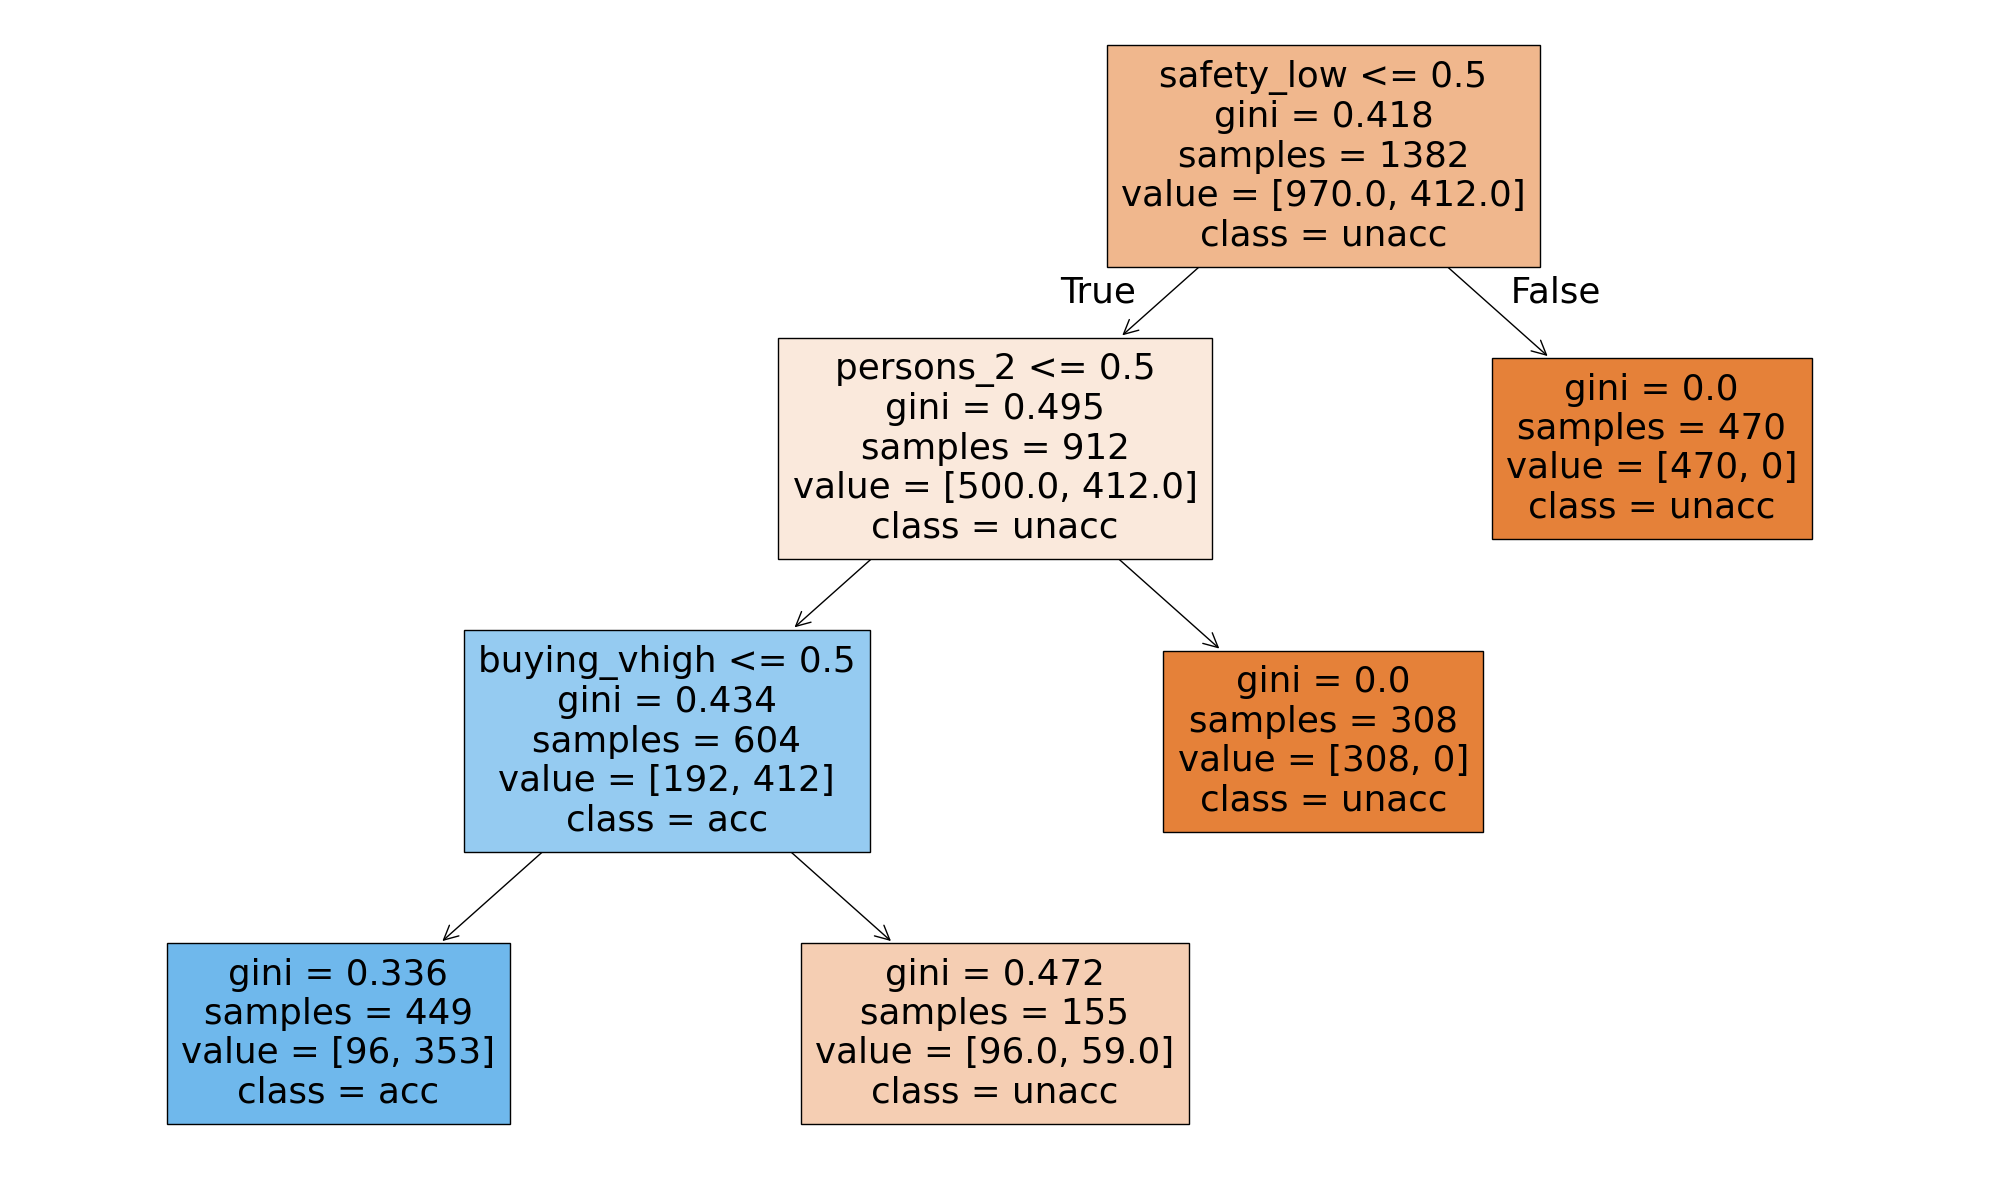

In [4]:
#Ex.) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Import models from scikit learn module:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

#Loading the dataset
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])

## 1a. Take a look at the dataset
print(df.head())

## 1b. Setting the target and predictor variables
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6])
y = df['accep']

## 1c. Examine the new features
print(X.columns)
print(len(X.columns))

## 2a. Performing the train-test split
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)

## 2b.Fitting the decision tree classifier
dt = DecisionTreeClassifier(max_depth=3, ccp_alpha=0.01,criterion='gini')
dt.fit(x_train, y_train)

## 3.Plotting the Tree
plt.figure(figsize=(20,12))
tree.plot_tree(dt, feature_names = x_train.columns, max_depth=5, class_names = ['unacc', 'acc'], label='all', filled=True)
plt.tight_layout()
plt.show()

# Implementing a decision Tree: 


 - **Root node** = top of the tree. Shows total `samples` and the class breakdown (e.g. unacc vs. acc) used to build the tree.
  - **Splits read True → left, False → right** at every node.
  - **Leaf node** = a box with no further branches. A decision ending here is assigned the **majority class** of that node (here: `unacc`).
  - **gini** appears in every box — it's the impurity measure that decides *how* each split is made (covered next exercise).

  ### The features (all categorical)
  - `buying` — purchase price: vhigh / high / med / low
  - `maint` — maintenance cost: vhigh / high / med / low
  - `doors` — number of doors: 2 / 3 / 4 / 5/ more
  - `persons` — capacity: 2 / 4 / more
  - `lugboot` — trunk size: small / med / big
  - `safety` — safety rating: low / med / high

  **Target:** acceptability — `unacc` (unacceptable) vs `acc` (acceptable)

In [1]:
#Ex.) 

frac_acc = 412/1382
print(f'Fraction of acceptable cars: {frac_acc}')
low_safety_class = 'unacc'
print(f'Cars with low safety: {low_safety_class}')
sample_class = 'unacc'
print(f'The classs of the sample car: {sample_class}')


Fraction of acceptable cars: 0.2981186685962373
Cars with low safety: unacc
The classs of the sample car: unacc


# Gini Impurity: 

 - **Idea:** measures how "mixed" the labels are in a node. Lower = purer = better split.
  - A node with only one class → **pure** → Gini = 0. A 50/50 mix → most impure.

  ### Formula (two classes, proportions p₁ and p₂ where p₂ = 1 − p₁)
  $$ Gini = 1 - (p_1^2 + p_2^2) = 1 - \big(p_1^2 + (1-p_1)^2\big) $$

  - p₁ = 0 or 1 → Gini = **0** (perfect separation)
  - p₁ = 0.5 → Gini = **0.5** (maximum impurity, classes perfectly balanced)

  ### General formula (C classes)
  $$ Gini = 1 - \sum_{i=1}^{C} p_i^2 $$

  ### Why it matters
  - A decision tree picks splits that **minimize Gini impurity** (= maximize purity) in the resulting child nodes.
  - In the A-vs-not-A example: the **bottom tree** is better — its leaves are pure (no debate), so we're more confident in the prediction.

![Two trees example](images/gini_two_trees_example.png)


![Gini impurity curve](images/gini_impurity_curve.png)

In [2]:
#Ex.) 

gini_root = 1.0 - ((412.0/1382.0)**2 + (970.0/1382.0)**2)
print(f'Gini impurity root node : {gini_root}')


gini_bottom_left = 1.0 - ((96.0/449.0)**2 + (353.0/449.0)**2)
print(f'Gini impurity bottom left node : {gini_bottom_left}')

Gini impurity root node : 0.41848785606128835
Gini impurity bottom left node : 0.33618880858725886


# Information Gain: 

 - Goal: leaves with **low Gini** — but *which feature* do we split on to get there?
  - **Information Gain (IG)** = how much impurity drops because of a split.
  - IG = (Gini *before* split) − (weighted Gini *after* split)
  - **Higher IG = better split.** IG = 0 → the split told us nothing.

![Information gain: safety_low split](images/info_gain_safety_split.png)

 **Before split (root):** Gini = 0.418, samples = 1382, value = [970, 412]

  Split sends:
  - **Left** = higher-safety cars → 912 samples, Gini = 0.495
  - **Right** = low-safety cars → 470 samples, Gini = 0.0  ← *pure leaf!*

  **Weighted Gini after split:**
  $$ \frac{912}{1382}(0.495) + \frac{470}{1382}(0) = 0.3267 $$

  **Information Gain:**
  $$ 0.4185 - 0.3267 = 0.0918 $$

  Lower weighted Gini than before → we gained info; the child nodes are purer.

In [3]:
#Ex.)

#1. Information gain at a pure node (i.e., node with no more branches!)
r = 0.5 # ratio of new split, could be anything
gini_pure_node = 0.0
gini_info_gain = r*gini_pure_node  + (1-r)*gini_pure_node 
print(f'Gini information gain pure node split safety_low >= .5 : {gini_info_gain}')

#2. Information gain at the 'persons_2' split
r_persons_2 = 604.0/912.0 # read ratio of the split from the tree!
gini_left_split = 0.434
gini_right_split = 0.0
initial_gini_persons_2 = 0.495

weighted_gini_persons_2 = r_persons_2*gini_left_split + (1-r_persons_2)*gini_right_split

gini_info_gain_persons_2 = initial_gini_persons_2 - weighted_gini_persons_2

print(f'Gini information gain node persons_2 : {gini_info_gain_persons_2}')

Gini information gain pure node split safety_low >= .5 : 0.0
Gini information gain node persons_2 : 0.20757017543859652


# How a Decision Tree is Built (Feature Split): 


  ### The core question
  - We split the root on `safety_low`, with information gain:
  $$ IG = 0.4185 - 0.3267 = 0.0918 $$
  - But **how does sklearn KNOW that's the best feature to split on first?**

  ### The answer: try them all
  - At every node, compute **information gain for every candidate feature**, then keep the largest:
  $$ \text{best feature} = \arg\max_{f}\; IG(f) $$
  - That's exactly what `DecisionTreeClassifier()` does under the hood at each split.

  ### Reminder — the formulas being used
  **Gini impurity** of a node (C classes, proportions $p_i$):
  $$ Gini = 1 - \sum_{i=1}^{C} p_i^2 $$

  **Information gain** of a split (parent → left/right children):
  $$ IG = Gini_{\text{parent}} - \left( \frac{n_{L}}{n}\,Gini_{L} + \frac{n_{R}}{n}\,Gini_{R} \right) $$

  where $n_L, n_R$ are the child sample counts and $n = n_L + n_R$.

  ### This exercise: test a rival feature — `persons_2`
  - `persons_2` is binary (0 or 1). Split rule:
    - $persons\_2 < 0.5$ (value 0) → **left**
    - $persons\_2 > 0.5$ (value 1) → **right**
  - Compute $IG$ for splitting on `persons_2`, then compare to `safety_low`'s $0.0918$.
  - Higher $IG$ ⇒ better root split.

  ### Two helper functions provided
  - `gini(...)` → returns $1 - \sum_i p_i^2$
  - `info_gain(...)` → returns $Gini_{\text{parent}} - \sum_{\text{child}} \frac{n_{\text{child}}}{n} Gini_{\text{child}}$
  - **Task:** read both and confirm they match the formulas above.

In [4]:
#Ex.) 

## The usual libraries, loading the dataset and performing the train-test split
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6])
y = df['accep']

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)

## Functions to calculate gini impurity and information gain

def gini(data):
    """calculate the Gini Impurity
    """
    data = pd.Series(data)
    return 1 - sum(data.value_counts(normalize=True)**2)
   
def info_gain(left, right, current_impurity):
    """Information Gain associated with creating a node/split data.
    Input: left, right are data in left branch, right branch, respectively
    current_impurity is the data impurity before splitting into left, right branches
    """
    # weight for gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_impurity - w * gini(left) - (1 - w) * gini(right)

#### -----------------------------------
## 1. Calculate sample sizes for a split on `persons_2`
left = y_train[x_train['persons_2'] == 0]
right = y_train[x_train['persons_2'] == 1]
len_left =  len(left)
len_right = len(right)
print('No. of cars with persons_2 == 0:', len_left)
print('No. of cars with persons_2 == 1:', len_right)

## 2. Gini impurity calculations
gi = gini(y_train)
gini_left = gini(left)
gini_right =  gini(right)

print('Original gini impurity (without splitting!):', gi)
print('Left split gini impurity:', gini_left)
print('Right split gini impurity:', gini_right)

## 3.Information gain when using feature `persons_2`
info_gain_persons_2 = info_gain(left, right, gi)
print(f'Information gain for persons_2:', info_gain_persons_2)

## 4. Which feature split maximizes information gain?
info_gain_list = []
for i in x_train.columns:
    left = y_train[x_train[i]==0]
    right = y_train[x_train[i]==1]
    info_gain_list.append([i, info_gain(left, right, gi)])

info_gain_table = pd.DataFrame(info_gain_list).sort_values(1,ascending=False)
print(f'Greatest impurity gain at:{info_gain_table.iloc[0,:]}')
print(info_gain_table)


No. of cars with persons_2 == 0: 917
No. of cars with persons_2 == 1: 465
Original gini impurity (without splitting!): 0.41848785606128835
Left split gini impurity: 0.49485722848081015
Right split gini impurity: 0.0
Information gain for persons_2: 0.09013468781461476
Greatest impurity gain at:0    safety_low
1      0.091603
Name: 19, dtype: object
                 0         1
19      safety_low  0.091603
12       persons_2  0.090135
18     safety_high  0.045116
14    persons_more  0.025261
13       persons_4  0.020254
7      maint_vhigh  0.013622
3     buying_vhigh  0.011001
20      safety_med  0.008480
17  lug_boot_small  0.006758
1       buying_low  0.006519
5        maint_low  0.005343
6        maint_med  0.004197
15    lug_boot_big  0.003913
2       buying_med  0.003338
8          doors_2  0.002021
0      buying_high  0.001094
4       maint_high  0.000530
10         doors_4  0.000423
16    lug_boot_med  0.000386
11     doors_5more  0.000325
9          doors_3  0.000036
